# 03 - Scheduler Simulation: Full Weekly Workload

This notebook visualizes the scheduler experiment that uses every valid submitted job available in each PM100 week. It complements the capped 1,200-jobs-per-week experiment.


In [1]:
from pathlib import Path
import pandas as pd
from IPython.display import Image, display

PROJECT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
RESULTS = PROJECT / 'results' / 'scheduler_full_workload'
print('Results directory:', RESULTS.relative_to(PROJECT))


Results directory: results\scheduler_full_workload


## Reproduce This Run

```bash
python scripts/01_run_carbon_prediction.py --max-rows 60000
python scripts/02_run_scheduler.py --num-weeks 0 --max-jobs 0 --split all --output-dir results/scheduler_full_workload
```

`--max-jobs 0` disables the weekly job cap.


In [2]:
metrics = pd.read_csv(RESULTS / 'scheduler_metrics.csv')
metrics


,policy,scheduled_jobs,skipped_jobs,total_actual_energy_kwh,total_actual_emissions_kg,total_predicted_emissions_kg,avg_wait_h,median_wait_h,p95_wait_h,avg_slowdown,max_processors_used,emissions_delta_vs_fcfs_kg,emissions_reduction_vs_fcfs_pct,avg_wait_delta_vs_fcfs_h
0,fcfs,58846.0,0.0,372652.568347,115771.435903,76307.390705,0.000000,0.000000,0.000000,1.000000,5551.0,0.000000,0.000000,0.000000
1,random,58846.0,0.0,372652.568347,115624.541863,75776.912483,11.737698,11.711667,22.758542,19.981476,1133.0,-146.894040,0.126883,11.737698
2,carbon_aware,58846.0,0.0,372652.568347,109468.840447,70622.975408,11.546072,11.722778,22.007431,19.973864,15680.0,-6302.595456,5.443999,11.546072


In [3]:
weekly = pd.read_csv(RESULTS / 'scheduler_weekly_metrics.csv')
carbon_weekly = weekly[weekly['policy'].eq('carbon_aware')].copy()
weekly_view = carbon_weekly[[
    'week_start', 'input_jobs', 'scheduled_jobs', 'skipped_jobs',
    'total_actual_emissions_kg', 'emissions_reduction_vs_fcfs_pct', 'avg_wait_h'
]]
weekly_view


,week_start,input_jobs,scheduled_jobs,skipped_jobs,total_actual_emissions_kg,emissions_reduction_vs_fcfs_pct,avg_wait_h
2,2020-05-04T00:00:00+00:00,4291.0,4291.0,0.0,4752.344142,9.974621,9.023732
5,2020-05-11T00:00:00+00:00,3062.0,3062.0,0.0,1206.969291,11.262731,11.424411
8,2020-05-18T00:00:00+00:00,7941.0,7941.0,0.0,2930.999836,6.334274,11.155704
11,2020-05-25T00:00:00+00:00,3153.0,3153.0,0.0,7794.235031,7.900845,10.741184
14,2020-06-01T00:00:00+00:00,2819.0,2819.0,0.0,21469.194784,4.161308,10.396847
17,2020-06-08T00:00:00+00:00,3672.0,3672.0,0.0,7255.875656,4.624447,11.635742
20,2020-06-15T00:00:00+00:00,15996.0,15996.0,0.0,14797.766712,4.972370,12.145402
23,2020-06-22T00:00:00+00:00,6015.0,6015.0,0.0,23805.496902,4.542577,11.666786
26,2020-06-29T00:00:00+00:00,5537.0,5537.0,0.0,17452.258978,5.609434,11.463862
29,2020-07-06T00:00:00+00:00,6360.0,6360.0,0.0,8003.699114,6.185424,13.100513


In [4]:
summary = {
    'weeks': int(carbon_weekly['week_index'].nunique()),
    'carbon_aware_jobs': int(carbon_weekly['scheduled_jobs'].sum()),
    'weighted_reduction_pct': float(metrics.loc[metrics['policy'].eq('carbon_aware'), 'emissions_reduction_vs_fcfs_pct'].iloc[0]),
    'weekly_reduction_mean_pct': float(carbon_weekly['emissions_reduction_vs_fcfs_pct'].mean()),
    'weekly_reduction_min_pct': float(carbon_weekly['emissions_reduction_vs_fcfs_pct'].min()),
    'weekly_reduction_max_pct': float(carbon_weekly['emissions_reduction_vs_fcfs_pct'].max()),
}
pd.Series(summary).to_frame('value')


,value
weeks,10.000000
carbon_aware_jobs,58846.000000
weighted_reduction_pct,5.443999
weekly_reduction_mean_pct,6.556803
weekly_reduction_min_pct,4.161308
weekly_reduction_max_pct,11.262731


## Final Three Weeks

These weeks are especially useful when discussing the later validation/test portion of the chronological prediction file.


In [5]:
savings = pd.read_csv(RESULTS / 'carbon_aware_weekly_savings.csv')
savings['week_start'] = pd.to_datetime(savings['week_start'])
savings.tail(3)


,week_index,week_start,fcfs_kg,carbon_aware_kg,saved_kg,reduction_pct
7,7,2020-06-22 00:00:00+00:00,24938.340284,23805.496902,1132.843381,4.542577
8,8,2020-06-29 00:00:00+00:00,18489.410166,17452.258978,1037.151189,5.609434
9,9,2020-07-06 00:00:00+00:00,8531.402574,8003.699114,527.703461,6.185424


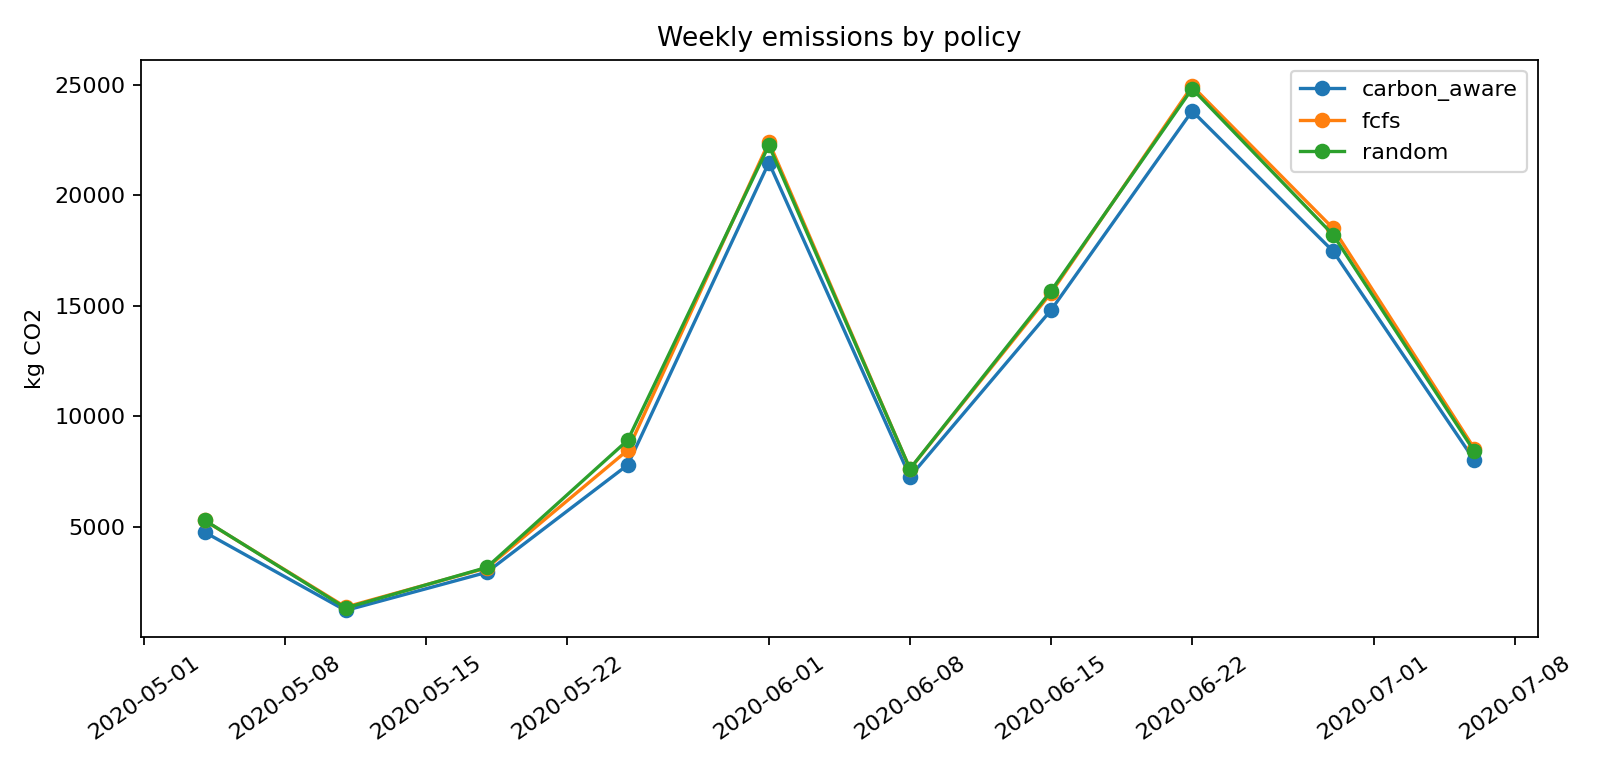

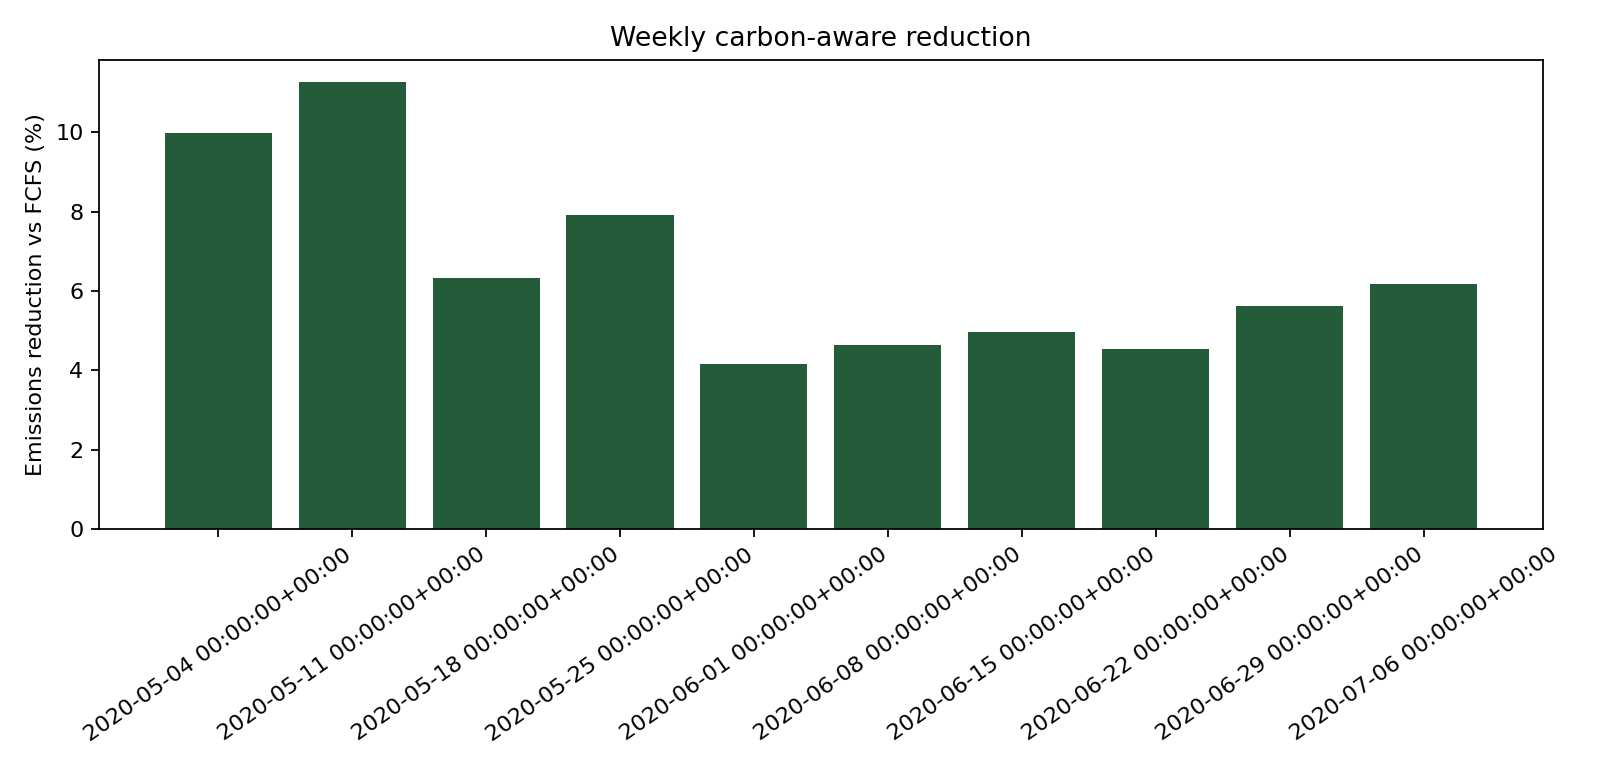

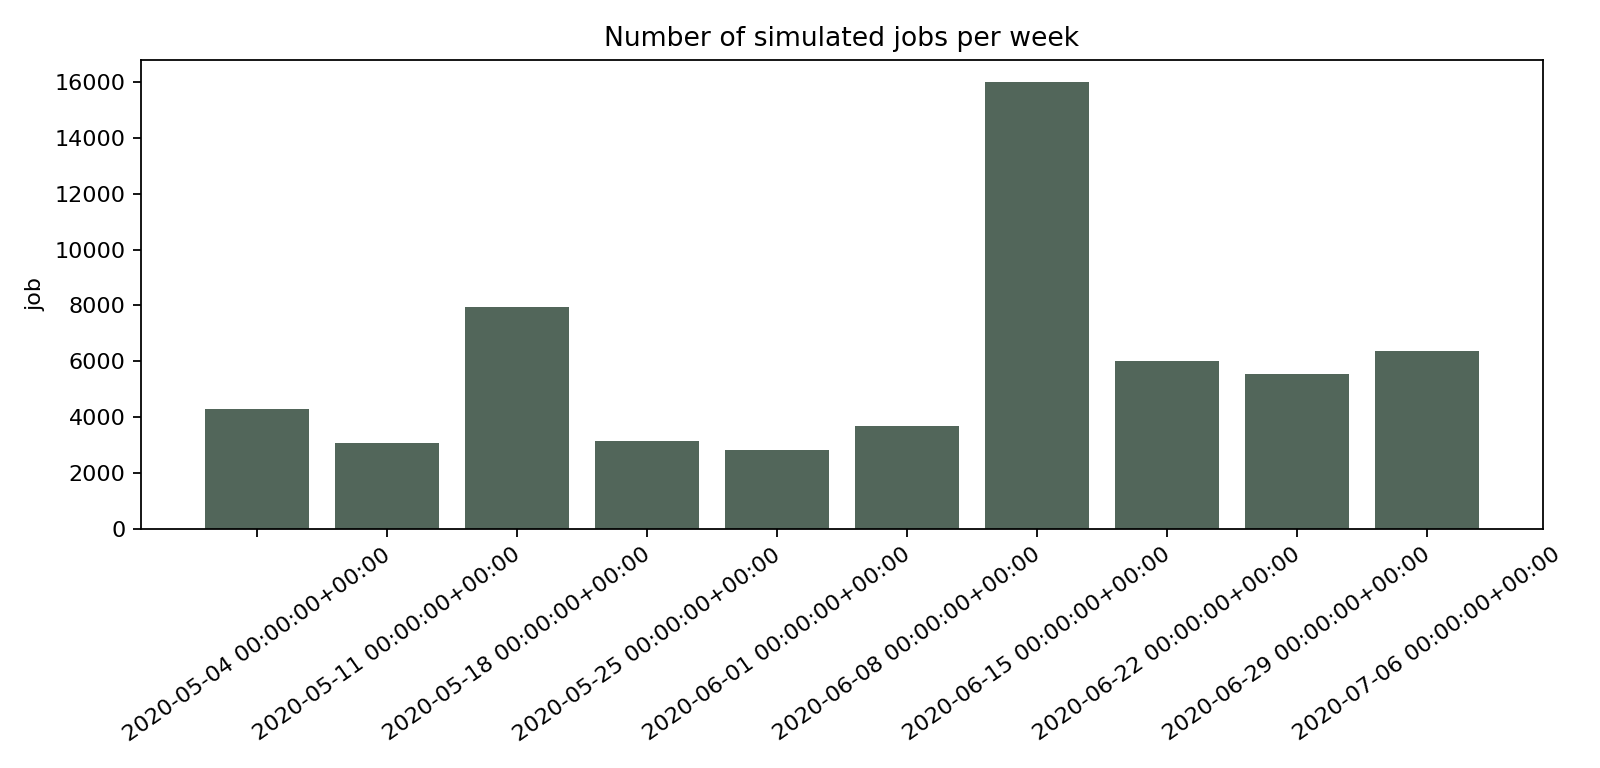

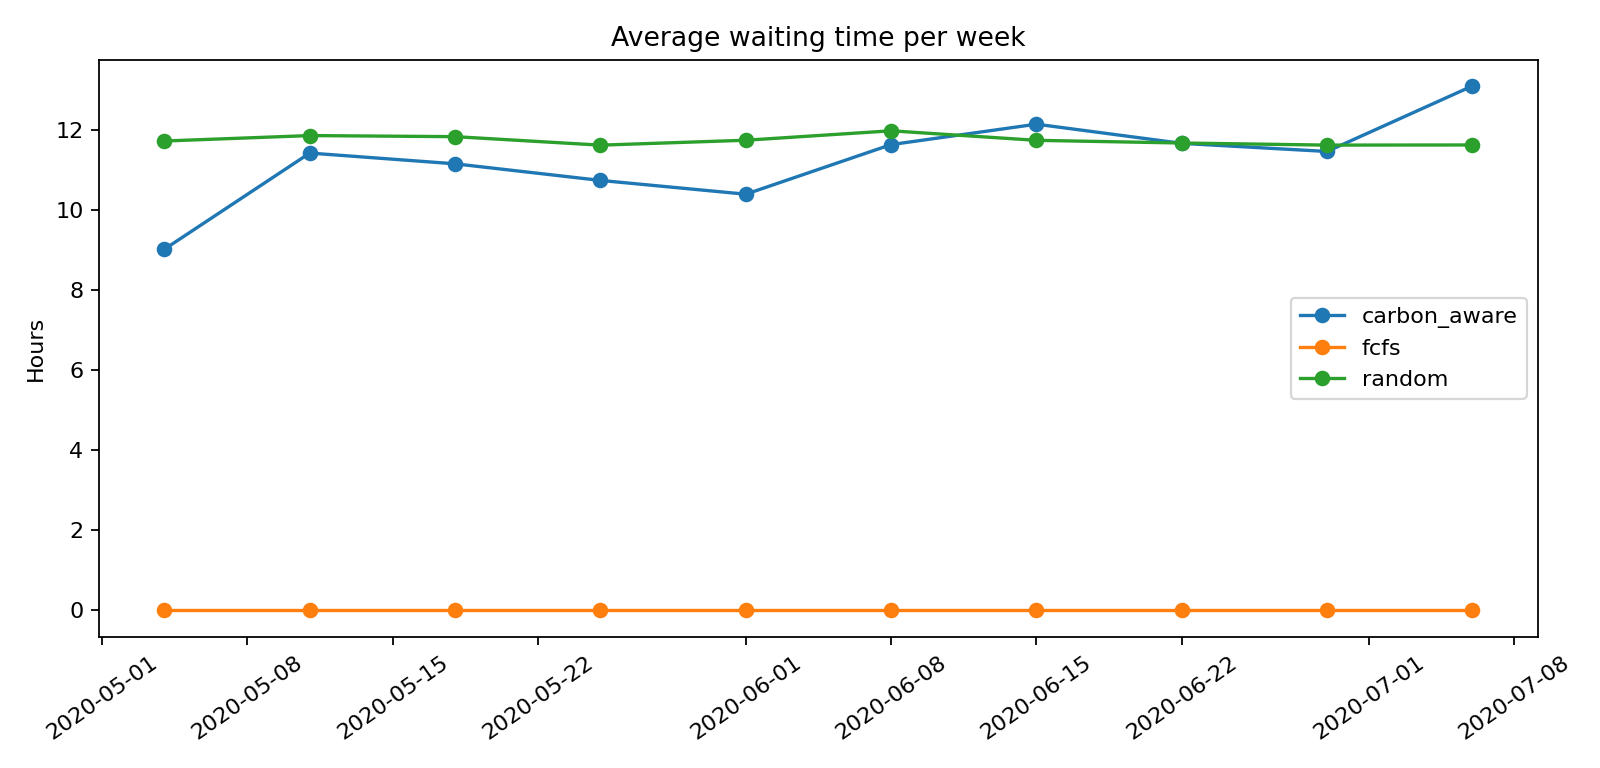

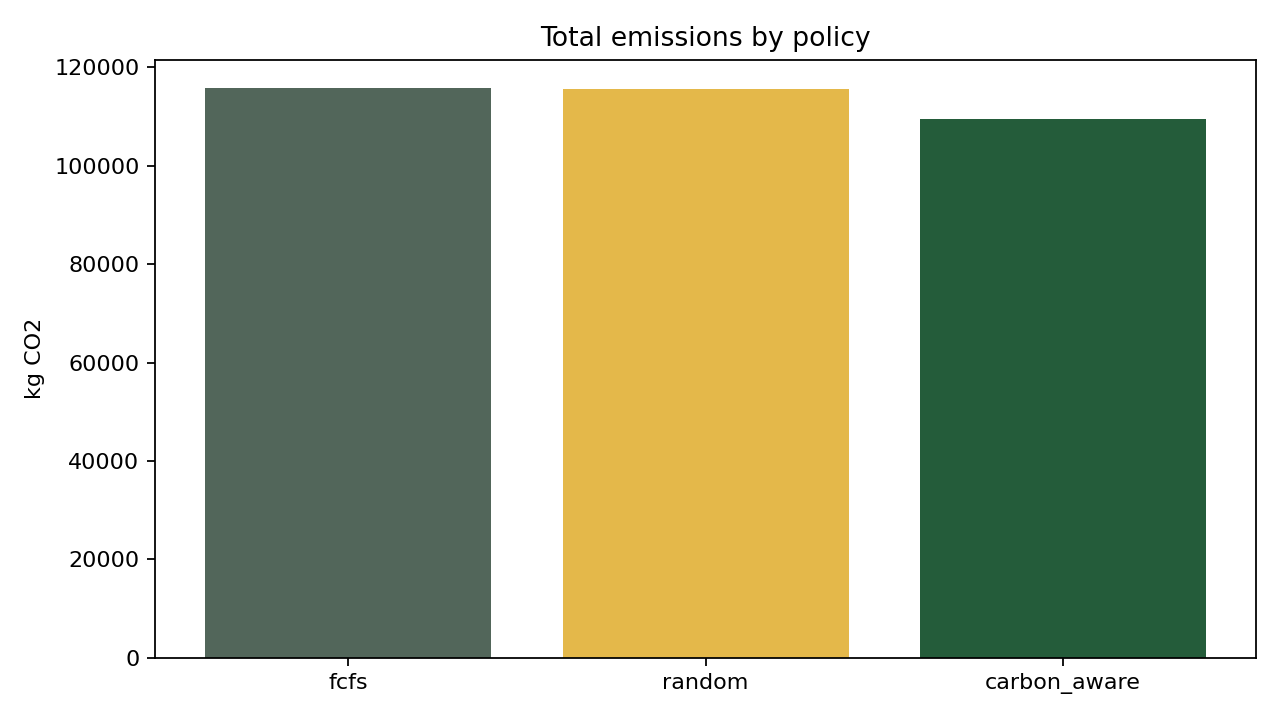

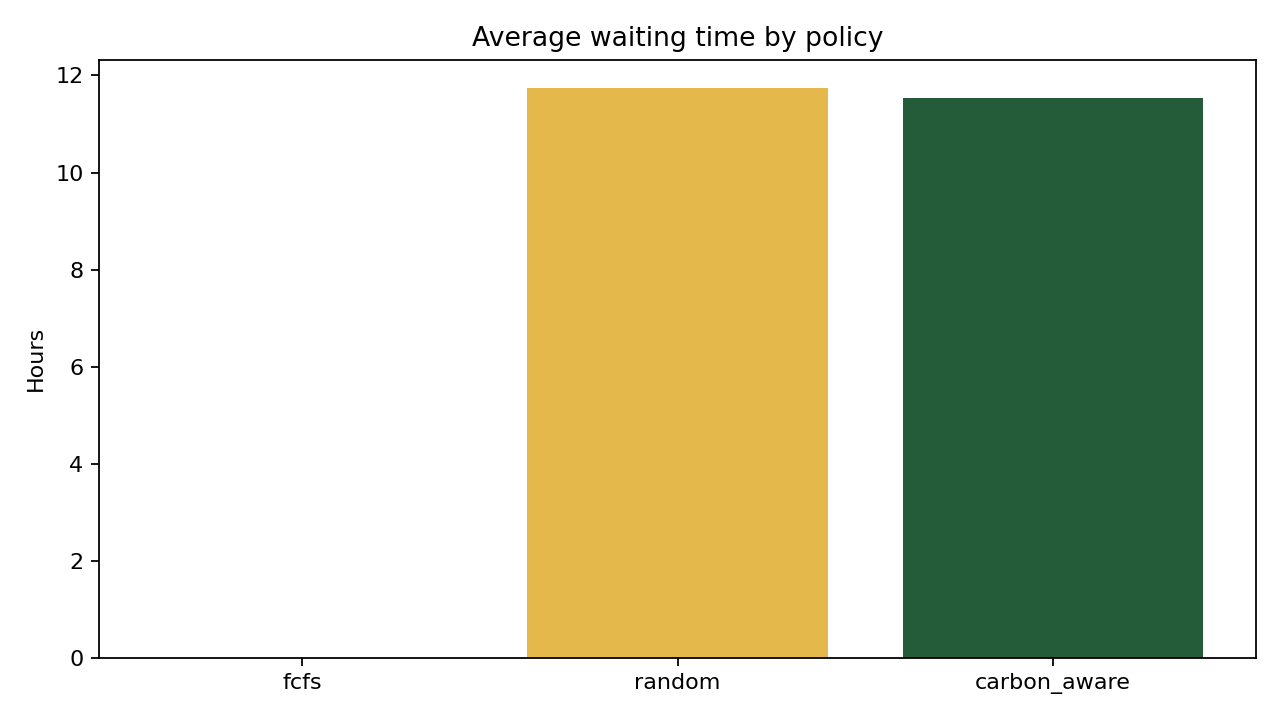

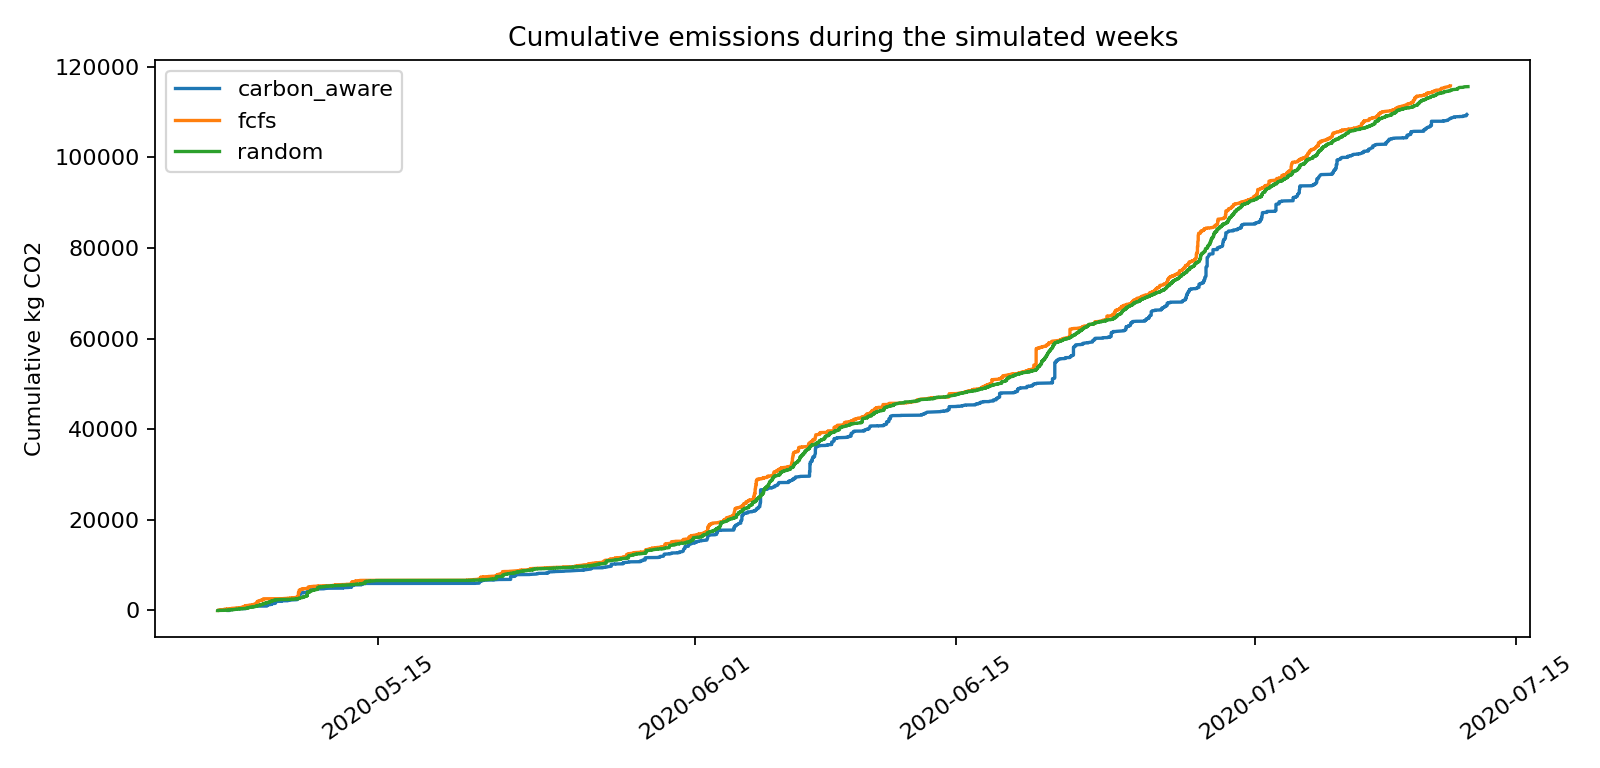

In [6]:
for name in [
    'scheduler_weekly_emissions.png',
    'scheduler_weekly_reduction_pct.png',
    'scheduler_weekly_jobs.png',
    'scheduler_weekly_wait.png',
    'scheduler_emissions_comparison.png',
    'scheduler_wait_comparison.png',
    'scheduler_cumulative_emissions.png',
]:
    display(Image(filename=str(RESULTS / name)))


## Interpretation

This full-workload run is the more direct workload-level simulation: every valid job in each available weekly window is scheduled. It preserves the same policy comparison while allowing the weekly job counts to reflect the trace.
